In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [59]:
df=pd.read_csv("penguins_size.csv")

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [61]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [62]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [63]:
df["species"].unique()

<StringArray>
['Adelie', 'Chinstrap', 'Gentoo']
Length: 3, dtype: str

In [64]:
df["island"].unique()

<StringArray>
['Torgersen', 'Biscoe', 'Dream']
Length: 3, dtype: str

<Axes: xlabel='species', ylabel='count'>

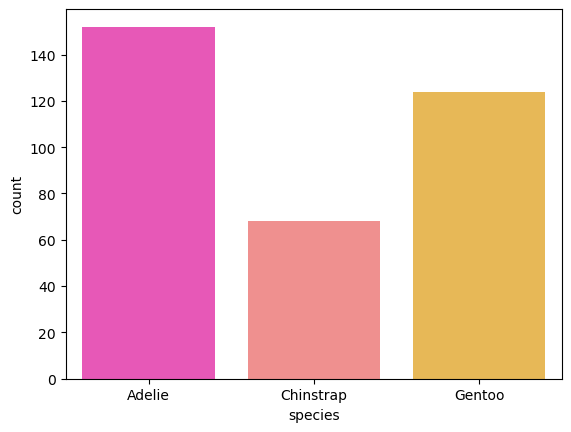

In [65]:
sns.countplot(data=df,x="species",hue =df["species"],palette='spring',legend=False)

<Axes: xlabel='island', ylabel='count'>

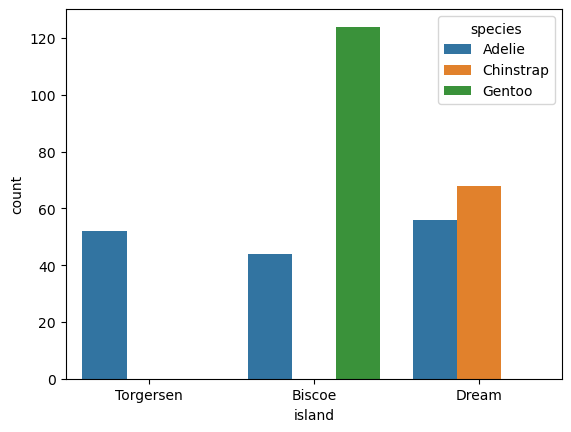

In [66]:
sns.countplot(data=df, x="island", hue="species")

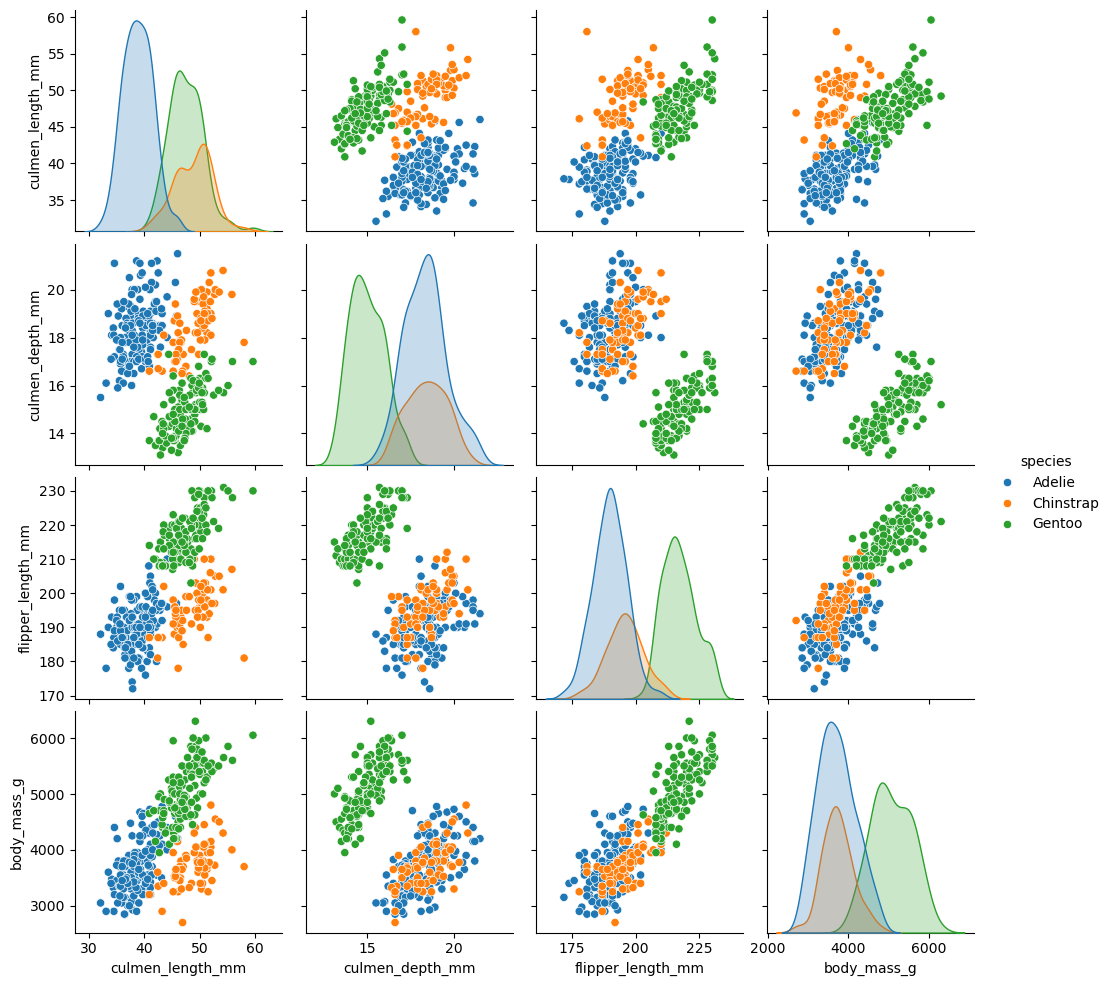

In [67]:
sns.pairplot(data=df,hue="species")

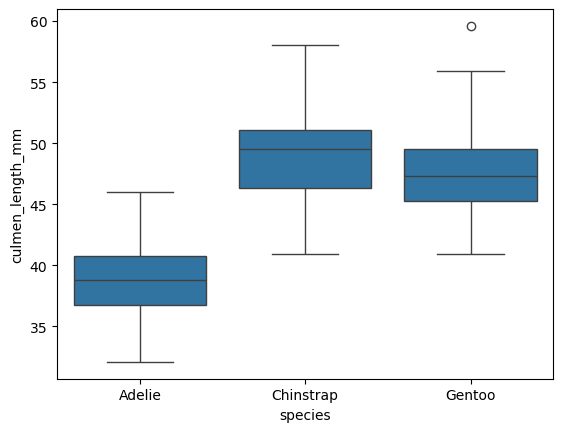

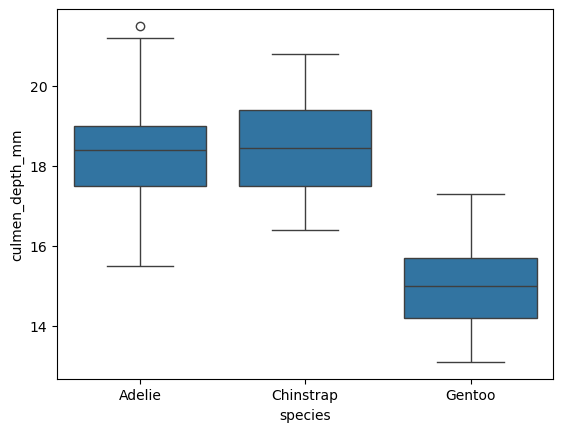

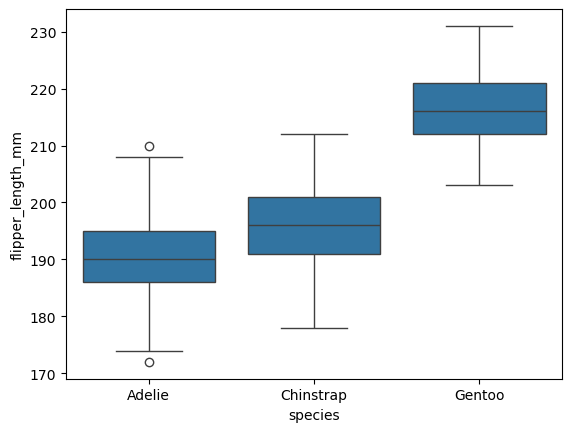

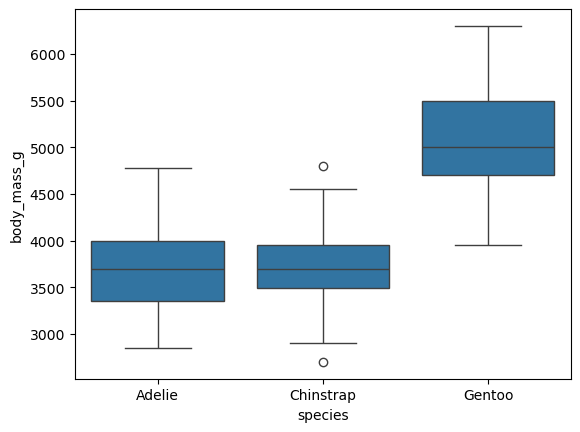

In [68]:
sns.boxplot(data=df,x="species",y="culmen_length_mm")
plt.show()
sns.boxplot(data=df,x="species",y="culmen_depth_mm")
plt.show()
sns.boxplot(data=df,x="species",y="flipper_length_mm")
plt.show()
sns.boxplot(data=df,x="species",y="body_mass_g")
plt.show()

In [69]:
df.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [70]:
df["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [71]:
df["island"].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [72]:
df["sex"].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

In [73]:
df[df["sex"] == "."]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,.


In [74]:
df.loc[336, 'sex'] = 'FEMALE'

In [75]:
df["sex"].value_counts()

sex
MALE      168
FEMALE    166
Name: count, dtype: int64

In [76]:
df["island"].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [77]:
df["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [78]:
df=df.drop("sex",axis=1)
df=df.drop("island",axis=1)

In [79]:
df=df.drop(339,axis=0)

In [80]:
df.isna().sum()

species              0
culmen_length_mm     1
culmen_depth_mm      1
flipper_length_mm    1
body_mass_g          1
dtype: int64

In [81]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [82]:
df["culmen_depth_mm"] = df["culmen_depth_mm"].fillna(df["culmen_depth_mm"].mean())
df["culmen_length_mm"] = df["culmen_length_mm"].fillna(df["culmen_length_mm"].mean())
df["flipper_length_mm"] = df["flipper_length_mm"].fillna(df["flipper_length_mm"].mean())
df["body_mass_g"] = df["body_mass_g"].fillna(df["body_mass_g"].mean())

In [83]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,343.000000,343.000000,343.000000,343.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.451596,1.971904,14.041141,800.781229
min,32.100000,13.100000,172.000000,2700.000000
25%,39.250000,15.600000,190.000000,3550.000000
50%,44.400000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [84]:
df.isna().sum()

species              0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
dtype: int64

In [85]:
X=df[["culmen_depth_mm","culmen_length_mm","flipper_length_mm","body_mass_g"]].values
y=df["species"].values

In [86]:
y

<StringArray>
['Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
 'Adelie', 'Adelie', 'Adelie',
 ...
 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo',
 'Gentoo', 'Gentoo', 'Gentoo']
Length: 343, dtype: str

In [87]:
y.ndim

1

In [88]:
X.ndim

2

#label Encoding (Species türleri string oldugu için)

In [89]:
from sklearn.preprocessing import LabelEncoder

In [90]:
le=LabelEncoder()
y = le.fit_transform(y)

In [91]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [92]:
from sklearn.model_selection import train_test_split

In [93]:
X_train,X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [94]:
X_train

array([[  18.9       ,   37.5       ,  179.        , 2975.        ],
       [  20.7       ,   39.6       ,  191.        , 3900.        ],
       [  17.15116959,   43.92192982,  200.91520468, 4201.75438596],
       ...,
       [  18.5       ,   42.8       ,  195.        , 4250.        ],
       [  18.8       ,   36.7       ,  187.        , 3800.        ],
       [  19.        ,   50.8       ,  210.        , 4100.        ]],
      shape=(274, 4))

In [95]:
y_train

array([0, 0, 0, 2, 1, 0, 2, 2, 1, 2, 0, 2, 1, 2, 0, 0, 2, 2, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 2, 0, 1, 0, 0, 2, 0, 0, 2, 2, 0, 0, 2, 2, 2, 0,
       0, 0, 0, 0, 2, 1, 2, 1, 2, 2, 2, 2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 1,
       0, 0, 0, 0, 2, 1, 0, 2, 1, 0, 1, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 2,
       1, 1, 2, 2, 0, 1, 1, 2, 0, 1, 0, 0, 0, 2, 0, 2, 1, 2, 1, 2, 2, 1,
       0, 1, 0, 1, 2, 2, 0, 0, 2, 2, 2, 2, 1, 2, 0, 2, 0, 0, 0, 0, 0, 2,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 2, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2, 0, 2,
       0, 1, 2, 2, 0, 1, 2, 2, 2, 0, 0, 2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0,
       2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 0, 2, 2, 2, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 2, 0, 1, 0,
       1, 0, 1, 2, 2, 2, 2, 1, 1, 1, 2, 1, 0, 1, 0, 0, 0, 1, 0, 2, 0, 0,
       2, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 0, 0,
       0, 1, 2, 1, 0, 0, 2, 0, 0, 1])

#Burda StandartScaler Yapılması gerekiyor Body binli civarda diğerleri 10 lu civarda ayni ölçekte olmali

In [96]:
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Scaler'ı oluştur
scaler = StandardScaler()

# 2. Train verisine göre ölçeği ÖĞREN ve UYGULA (fit_transform)
X_train = scaler.fit_transform(X_train)

# 3. Öğrenilmiş ölçeği Test verisine UYGULA
X_test = scaler.transform(X_test)

# 4. ÖĞRENMİŞ DOLU SCALER'I HEMEN BURADA KAYDET!
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [97]:
X_train = torch.as_tensor( X_train,dtype=torch.float32)
X_test = torch.as_tensor( X_test,dtype=torch.float32)
y_train = torch.as_tensor( y_train,dtype=torch.long)
y_test = torch.as_tensor( y_test ,dtype=torch.long)

In [98]:
# Burda CrossEntroyLossdan dolayı y'ler unsqueeze yapılmadı binary classification olsa yapılacaktı boyut uyuşmazlığından dolayı

In [99]:
print(X_train.shape,X_test.shape)
print(y_train.shape,y_test.shape)

torch.Size([274, 4]) torch.Size([69, 4])
torch.Size([274]) torch.Size([69])


In [100]:
from torch import nn

In [101]:
class PenguinMultiClassification(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(4,16),
            nn.ReLU(),
            nn.Linear(16,16),
            nn.ReLU(),
            nn.Linear(16,16),
            nn.ReLU(),
            nn.Linear(16,3)
         )
    
    def forward(self,x):
          return self.linear_layer_stack(x)

In [102]:
model=PenguinMultiClassification()
loss_fn=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [103]:
def calculate_accruracy(y_true,y_pred):
    correct=torch.eq(y_true,y_pred).sum().item()
    acc=(correct/len(y_pred))*100
    return acc

In [104]:
epochs=200

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):

    model.train()

    logits = model(X_train)
    loss =loss_fn(logits,y_train)

    pred = torch.softmax(logits,dim=1).argmax(dim=1)
    acc = calculate_accruracy(y_train,pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_accuracies.append(acc)

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits,y_test)
        test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)
        test_acc = calculate_accruracy(y_test,test_pred)
    test_losses.append(test_loss.item())
    test_accuracies.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch: {epoch} , Loss : {loss} , Accuracy: {acc}, Test_loss : {test_loss},Test_accuracy : {test_acc}")
    

Epoch: 0 , Loss : 1.0831471681594849 , Accuracy: 35.4014598540146, Test_loss : 1.0816831588745117,Test_accuracy : 36.231884057971016
Epoch: 20 , Loss : 1.0360023975372314 , Accuracy: 77.00729927007299, Test_loss : 1.0366103649139404,Test_accuracy : 75.36231884057972
Epoch: 40 , Loss : 0.9571089744567871 , Accuracy: 80.2919708029197, Test_loss : 0.9594875574111938,Test_accuracy : 78.26086956521739
Epoch: 60 , Loss : 0.8176760673522949 , Accuracy: 80.2919708029197, Test_loss : 0.8228629231452942,Test_accuracy : 78.26086956521739
Epoch: 80 , Loss : 0.6134414076805115 , Accuracy: 80.65693430656934, Test_loss : 0.6210863590240479,Test_accuracy : 79.71014492753623
Epoch: 100 , Loss : 0.4039456248283386 , Accuracy: 91.97080291970804, Test_loss : 0.41207560896873474,Test_accuracy : 88.40579710144928
Epoch: 120 , Loss : 0.2348882555961609 , Accuracy: 96.35036496350365, Test_loss : 0.239155113697052,Test_accuracy : 98.55072463768117
Epoch: 140 , Loss : 0.1334417462348938 , Accuracy: 97.810218978

# Visualization

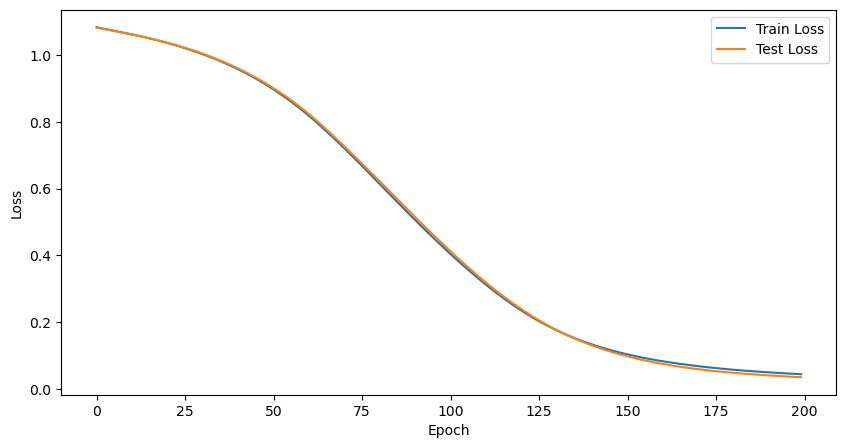

In [105]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

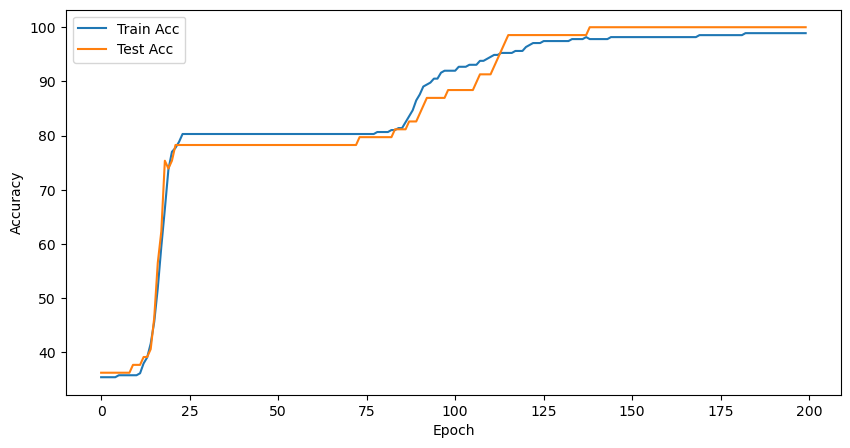

In [106]:
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [107]:
from torchmetrics.classification import MulticlassConfusionMatrix

In [108]:
cm = MulticlassConfusionMatrix(num_classes=3)

In [109]:
matrix = cm(test_pred,y_test)

In [110]:
print(matrix)

tensor([[30,  0,  0],
        [ 0, 14,  0],
        [ 0,  0, 25]])


In [111]:
from torchmetrics.utilities.plot import plot_confusion_matrix

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

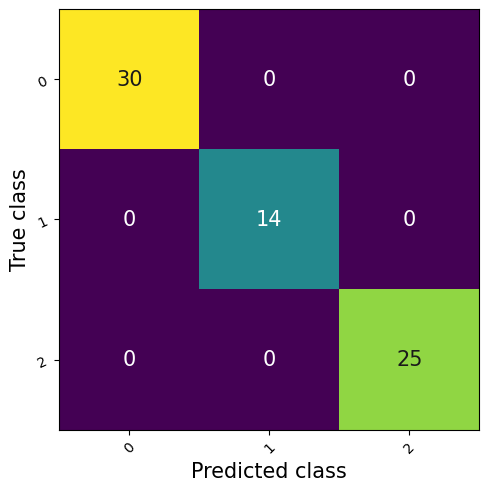

In [112]:
plot_confusion_matrix(matrix)

# Save

In [113]:
from pathlib import Path

In [114]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

MODEL_NAME = "palmer_penguin_multi_classification.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model.state_dict(),f=MODEL_SAVE_PATH)